# Phase diagrams with `aiomfac_py.diagram`

This notebook demonstrates the phase-diagram functions of `aiomfac_py` (see `docs/phase_diagrams.md` for the
full manual):

1. boundary tracing along RH (`trace`), deliquescence points and particle properties;
2. composition–RH diagrams (`phase_map`, `plot_phase_map`, `label_regions`), with the
   (NH4)2SO4–NH4NO3–H2O system and its double salts as the main example;
3. deliquescence curves and pH of acid sulfate particles (`rh_profile`) in the UHAERO coordinates;
4. a particle with an organic component (liquid–liquid phase separation);
5. liquid–liquid diagrams of neutral mixtures (`binary_mixing_curve`, `ternary_lle`, `plot_ternary`).

The diagrams follow the UHAERO papers (Amundson et al., 2006, *Atmos. Chem. Phys.* 6, 975; 2007, *Atmos. Chem.
Phys.* 7, 4675), computed here with AIOMFAC. The whole notebook runs in about 10 minutes on one CPU core.

### Setup

In [1]:
from pathlib import Path
import subprocess, sys

REPO_DIR = Path("/content/aiomfac-python")
try:
    import aiomfac_py
    from aiomfac_py import diagram as dg            # needs scipy
    import matplotlib
except ImportError:                                  # Google Colab: clone and install
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                       check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --smiles")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy", "matplotlib"], check=True)
    import aiomfac_py
    from aiomfac_py import diagram as dg

import time, warnings
import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component
from aiomfac_py.phase_equilibrium import PhaseEquilibrium
from aiomfac_py.sle import binary_saturation

warnings.filterwarnings("ignore")      # overflow warnings from trial points of the solver
T = 298.15
print("aiomfac_py", aiomfac_py.__version__)

aiomfac_py 1.3.0


## 1. Tracing phase boundaries along RH

`trace` solves the equilibrium on an RH grid (high to low RH, warm starts) and bisects every interval where the
phase state changes, here to 1e-4 in RH. For a single salt the only boundary is the deliquescence RH, which must
equal the saturation water activity of the salt (`sle.binary_saturation`).

In [2]:
pe = PhaseEquilibrium([], ["NH4+", "SO4--"], T_K=T)
t0 = time.time()
t = dg.trace(pe, {"NH4+": 2.0, "SO4--": 1.0}, n=16)
print(f"{t.n_solves} solves, {time.time() - t0:.1f} s")
for b in t.boundaries:
    print(f"RH = {b.rh:.5f} (bracket {b.rh_hi - b.rh_lo:.1e})  {b.kind}: {b.below.label} -> {b.above.label}")
print("binary_saturation a_w:", round(binary_saturation("ammonium_sulfate", T)["aw"], 5))
print("intervals:", [(round(a, 3), round(b, 3), s.label) for a, b, s in t.intervals()])

26 solves, 1.5 s
RH = 0.79875 (bracket 6.1e-05)  deliquescence: ammonium_sulfate -> L
binary_saturation a_w: 0.79875
intervals: [(0.05, 0.799, 'ammonium_sulfate'), (0.799, 0.98, 'L')]


Several boundaries in one trace: MgCl2 particles show the hydrate transition MgCl2·4H2O → MgCl2·6H2O
(bischofite) at low RH before deliquescence.

In [3]:
pe = PhaseEquilibrium([], ["Mg++", "Cl-"], T_K=T)
t = dg.trace(pe, {"Mg++": 1.0, "Cl-": 2.0}, n=24)
for b in t.boundaries:
    print(f"RH = {b.rh:.4f}  {b.kind:16s} {b.below.label} -> {b.above.label}")

RH = 0.0641  solid transition MgCl2_4H2O -> bischofite
RH = 0.3705  deliquescence    bischofite -> L


### Deliquescence point and particle properties

`deliquescence_point` returns only the full deliquescence RH and the first solid; `method="si"` follows the
solid-free liquid and finds where the first solid saturates, which is faster. `rh_profile` gives the relative
particle mass W_p/W_dry, the liquid water and the pH along RH.

(0.7560839843749998, ('halite',))


(0.7560649044733628, ('halite',))


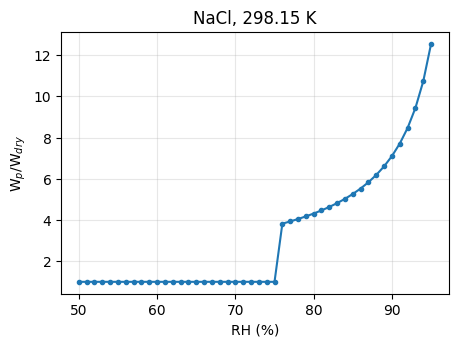

In [4]:
pe = PhaseEquilibrium([], ["Na+", "Cl-"], T_K=T)
feed = {"Na+": 1.0, "Cl-": 1.0}
print(dg.deliquescence_point(pe, feed))
print(dg.deliquescence_point(pe, feed, method="si"))
rh = np.round(np.arange(0.50, 0.951, 0.01), 3)
p = dg.rh_profile(pe, feed, rh)
plt.figure(figsize=(5, 3.4))
plt.plot(100 * rh, p["rel_mass"], "-o", ms=3)
plt.xlabel("RH (%)"); plt.ylabel("W$_p$/W$_{dry}$"); plt.title("NaCl, 298.15 K"); plt.grid(alpha=0.3)
plt.show()

## 2. Composition–RH diagram: (NH4)2SO4 + NH4NO3

The composition parameter is the mole fraction of (NH4)2SO4 in the dry salt. The solid database contains the
double salts (NH4)2SO4·2NH4NO3 and (NH4)2SO4·3NH4NO3 (Clegg et al., 1998), so the diagram has three invariant
points. `phase_map` refines x where the boundary topology changes (eutonic and peritectic points).

In [5]:
pe = PhaseEquilibrium([], ["NH4+", "SO4--", "NO3-"], T_K=T)
feed = lambda x: {"NH4+": 2 * x + (1 - x), "SO4--": x, "NO3-": 1 - x}
t0 = time.time()
pm = dg.phase_map(pe, feed, [0.005, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 0.995], x_label="x((NH$_4$)$_2$SO$_4$) in dry salt",
                  n=20, rh_min=0.4, rh_max=0.9, x_tol=0.02)
print(f"{len(pm.x)} compositions, {sum(t.n_solves for t in pm.traces)} solves, {time.time() - t0:.0f} s")
for r in pm.to_records()[:6]:
    print(r)

21 compositions, 1096 solves, 92 s
{'x': 0.005, 'rh': 0.5692280016447369, 'rh_lo': 0.569202302631579, 'rh_hi': 0.5692537006578948, 'below': 'AS_3AN + ammonium_nitrate', 'above': 'L + ammonium_nitrate', 'kind': 'deliquescence', 'resolved': True}
{'x': 0.005, 'rh': 0.6103946083470395, 'rh_lo': 0.6103656969572369, 'rh_hi': 0.6104235197368422, 'below': 'L + ammonium_nitrate', 'above': 'L', 'kind': 'deliquescence', 'resolved': True}
{'x': 0.1, 'rh': 0.5692280016447369, 'rh_lo': 0.569202302631579, 'rh_hi': 0.5692537006578948, 'below': 'AS_3AN + ammonium_nitrate', 'above': 'L + ammonium_nitrate', 'kind': 'deliquescence', 'resolved': True}
{'x': 0.1, 'rh': 0.5725913599917762, 'rh_lo': 0.5725624486019736, 'rh_hi': 0.5726202713815789, 'below': 'L + ammonium_nitrate', 'above': 'L', 'kind': 'deliquescence', 'resolved': True}
{'x': 0.1125, 'rh': 0.5692280016447369, 'rh_lo': 0.569202302631579, 'rh_hi': 0.5692537006578948, 'below': 'AS_3AN + ammonium_nitrate', 'above': 'L + AS_3AN', 'kind': 'deliques

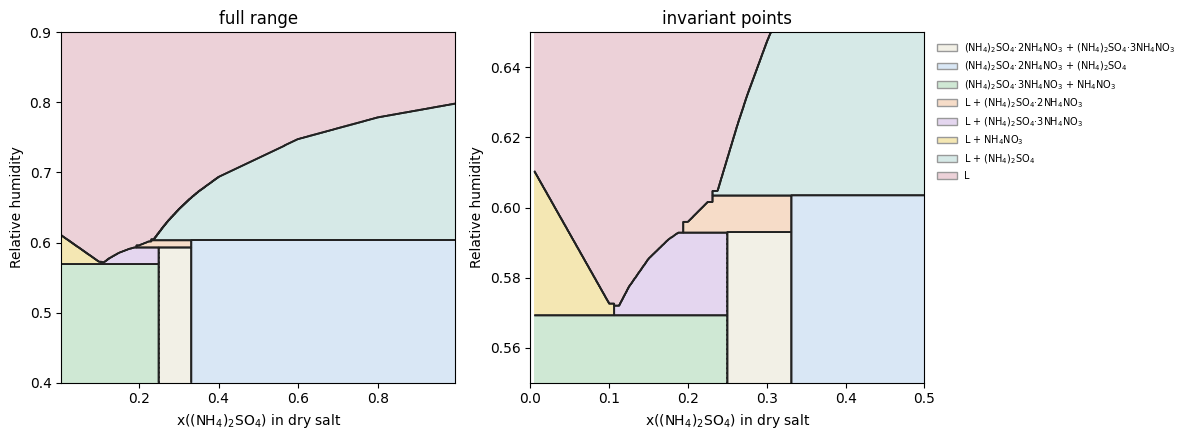

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
dg.plot_phase_map(pm, ax=axs[0], legend=False, rh_points=1500, x_points=800)
axs[0].set_title("full range")
dg.plot_phase_map(pm, ax=axs[1], rh_points=6000, x_points=2000)
axs[1].set_ylim(0.55, 0.65); axs[1].set_xlim(0, 0.5); axs[1].set_title("invariant points")
plt.tight_layout(); plt.show()

Line drawing with letter labels, as in the UHAERO papers (A = (NH4)2SO4, D = NH4NO3, E = (NH4)2SO4·2NH4NO3,
F = (NH4)2SO4·3NH4NO3). The state that exists at the single composition x = 0.25 (pure (NH4)2SO4·3NH4NO3) is drawn as
a dotted line.

[(0.25, 0.4, 0.5929738898026317, PhaseState(n_liquids=0, solids=('AS_3AN',)))]


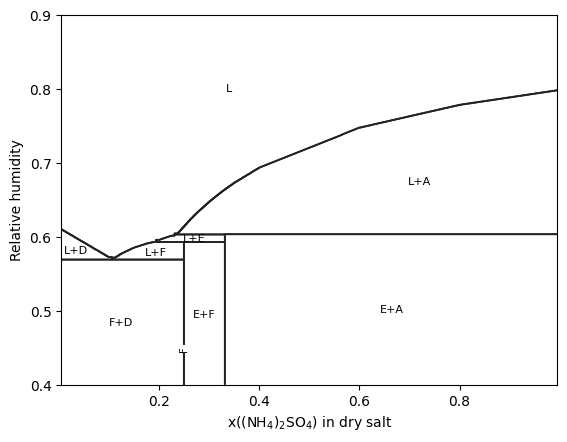

In [7]:
LETTERS = {"ammonium_sulfate": "A", "letovicite": "B", "ammonium_bisulfate": "C", "ammonium_nitrate": "D",
           "AS_2AN": "E", "AS_3AN": "F", "AHS_AN": "G"}
ax = dg.plot_phase_map(pm, legend=False, colors={s: "white" for s in pm.states()}, rh_points=1500, x_points=800)
dg.label_regions(ax, pm, LETTERS, min_cells=300)
print(dg.singular_lines(pm))
plt.show()

## 3. Acid sulfate particles: deliquescence curves and pH

UHAERO coordinates: ammonium fraction X = NH4+/(NH4+ + H+) and sulfate fraction Y = SO4/(SO4 + NO3), per mol of
cation. Below, Y = 1 (NH4+/H+/SO4--) at X = 0.9, 0.73 and 0.6 (Amundson et al., 2006, Fig. 3a). The pH is shown on
the mole-fraction scale used in the paper (pH_x = pH + 1.744).

X = 0.9: full deliquescence at RH = 0.7782, first solid ('ammonium_sulfate',)


X = 0.73: full deliquescence at RH = 0.7114, first solid ('ammonium_sulfate',)


X = 0.6: full deliquescence at RH = 0.6681, first solid ('letovicite',)


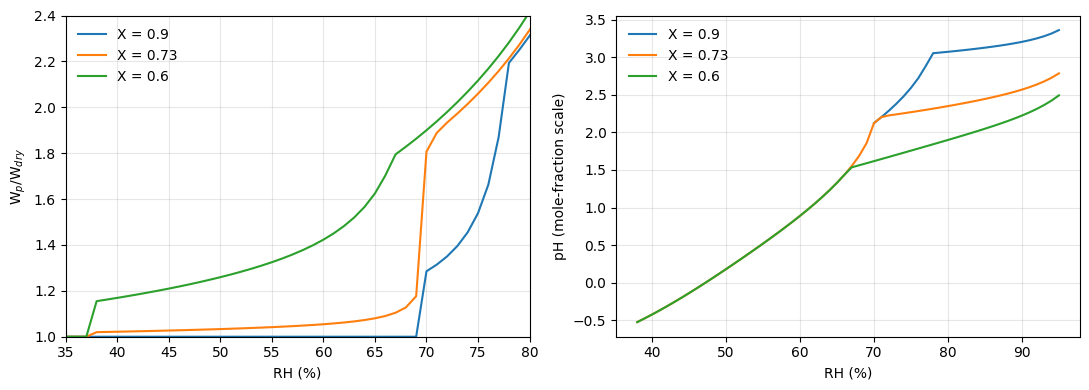

In [8]:
def uhaero_feed(X, Y):
    f = {"NH4+": X, "H+": 1 - X, "SO4--": Y / (1 + Y), "NO3-": (1 - Y) / (1 + Y)}
    return {k: v for k, v in f.items() if v > 1e-12}

pe = PhaseEquilibrium([], ["NH4+", "H+", "SO4--"], T_K=T)
rh = np.round(np.arange(0.30, 0.951, 0.01), 3)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for X in (0.9, 0.73, 0.6):
    p = dg.rh_profile(pe, uhaero_feed(X, 1.0), rh)
    axs[0].plot(100 * rh, p["rel_mass"], label=f"X = {X}")
    axs[1].plot(100 * rh, p["pH"] + 1.744, label=f"X = {X}")
    drh, solids = dg.deliquescence_point(pe, uhaero_feed(X, 1.0), method="si")
    print(f"X = {X}: full deliquescence at RH = {drh:.4f}, first solid {solids}")
axs[0].set_ylim(1, 2.4); axs[0].set_xlim(35, 80); axs[0].set_ylabel("W$_p$/W$_{dry}$")
axs[1].set_ylabel("pH (mole-fraction scale)")
for ax in axs:
    ax.set_xlabel("RH (%)"); ax.legend(frameon=False); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. A particle with an organic component

(NH4)2SO4 with pinic acid (from its SMILES via S2AS). With an organic, a liquid is present at every RH. Here the
organic-rich liquid and the salt solution stay separate over the whole range (state 2L above the deliquescence RH,
L + (NH4)2SO4 below it), so the only boundary is the deliquescence of the salt, which the organic barely shifts; in
the metastable mode (no solids) the particle is phase-separated at every RH. `pie_composition` gives the content of
each phase.

In [9]:
from aiomfac_py.s2as import smiles_to_components
org = smiles_to_components(["CC1(C)C(CC1CC(=O)O)C(=O)O"]).components[1]
org = Component(2, "pinic acid", org.subgroups)
pe = PhaseEquilibrium([org], ["NH4+", "SO4--"], T_K=T)
feed = {"NH4+": 2.0, "SO4--": 1.0, "pinic acid": 0.75}
t0 = time.time()
t = dg.trace(pe, feed, n=16, rh_min=0.3, rh_max=0.95)
tm = dg.trace(pe, feed, n=16, rh_min=0.3, rh_max=0.95, mode="metastable")
print(f"{time.time() - t0:.0f} s")
for name, tr in (("equilibrium", t), ("metastable", tm)):
    print(name, [(round(a, 4), round(b, 4), s.label) for a, b, s in tr.intervals()])
res = pe.solve(feed, 0.85)
for label, parts in dg.pie_composition(res):
    print(label, {k: round(v, 3) for k, v in parts.items()})

6 s
equilibrium [(0.3, 0.7986, 'L + ammonium_sulfate'), (0.7986, 0.95, '2L')]
metastable [(0.3, 0.95, '2L')]
L1 {'water': 1.475, 'pinic acid': 0.745, 'ions': 0.023}
L2 {'water': 12.683, 'pinic acid': 0.005, 'ions': 2.977}


## 5. Liquid–liquid equilibrium of neutral mixtures

`binary_mixing_curve` evaluates the normalized Gibbs energy of mixing g = Σ x ln a of a binary mixture and finds
the miscibility gaps from its lower convex hull; `ternary_lle` does the same over the composition triangle and
classifies the hull triangles into one-, two- and three-phase regions. Example: water / 1-hexacosanol / pinic acid
(Amundson et al., 2007, Fig. 2).

water / pinic acid miscibility gap (x of pinic acid): [(0.008485, 0.208085)]


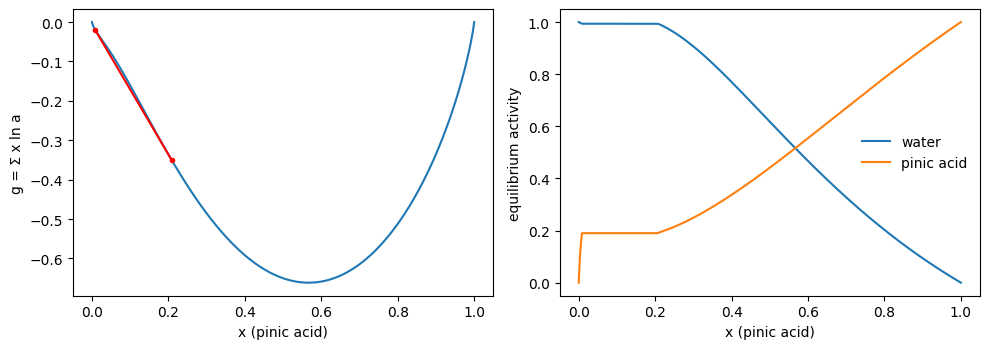

In [10]:
W = Component(1, "Water", ((16, 1),))
hexacosanol = Component(2, "1-hexacosanol", smiles_to_components(["C" * 25 + "CO"]).components[1].subgroups)
pinic = Component(3, "pinic acid", org.subgroups)

c = dg.binary_mixing_curve([W, Component(2, "pinic acid", pinic.subgroups)], T)
print("water / pinic acid miscibility gap (x of pinic acid):", c["splits"])
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
axs[0].plot(c["x"], c["g"]); axs[0].set_ylabel("g = Σ x ln a"); axs[0].set_xlabel("x (pinic acid)")
for a, b in c["splits"]:
    axs[0].plot([a, b], np.interp([a, b], c["x"], c["g"]), "ro-", ms=3)
axs[1].plot(c["x"], c["a1"], label="water"); axs[1].plot(c["x"], c["a2"], label="pinic acid")
axs[1].set_xlabel("x (pinic acid)"); axs[1].set_ylabel("equilibrium activity"); axs[1].legend(frameon=False)
plt.tight_layout(); plt.show()

24613 grid points, 5.8 s
three-phase triangle (x_hexacosanol, x_pinic): [[[0.0, 0.21], [0.745, 0.125], [0.0, 0.01]]]
equilibrium at x_hex = 0.3, x_pinic = 0.1: {'n_phases': 3, 'activities': array([0.99360169, 0.79660923, 0.19086057])}


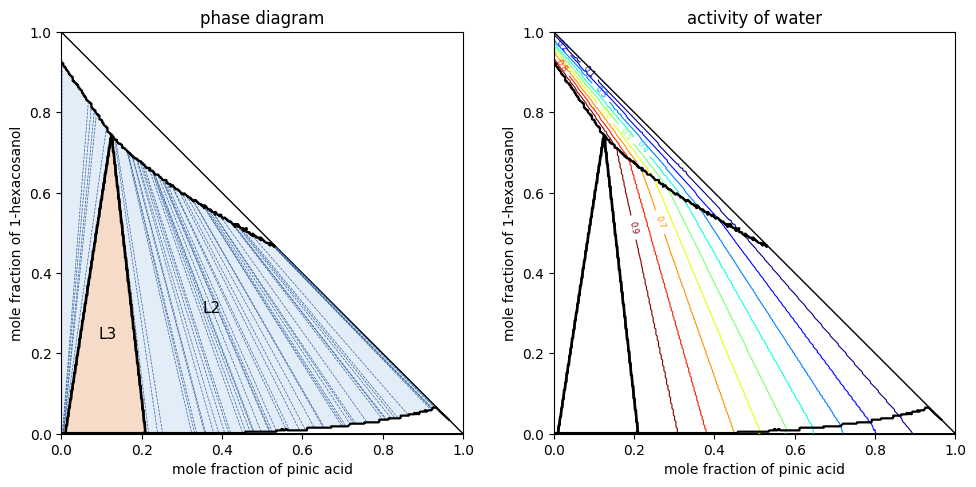

In [11]:
t0 = time.time()
td = dg.ternary_lle([W, hexacosanol, pinic], T)
print(f"{len(td.P)} grid points, {time.time() - t0:.1f} s")
print("three-phase triangle (x_hexacosanol, x_pinic):", [np.round(v, 3).tolist() for v in td.three_phase])
print("equilibrium at x_hex = 0.3, x_pinic = 0.1:", td.equilibrium(0.3, 0.1))
fig, axs = plt.subplots(1, 2, figsize=(10, 4.8))
dg.plot_ternary(td, ax=axs[0]); axs[0].set_title("phase diagram")
dg.plot_ternary(td, ax=axs[1], show=0); axs[1].set_title("activity of water")
plt.tight_layout(); plt.show()

## Further material

* `docs/phase_diagrams.md` — the user manual of these functions (concepts, reference, numerical method, limits).
* `tools/uhaero2006_figures.py`, `tools/uhaero2007_figures.py` — all figures of the two UHAERO papers with AIOMFAC
  (X–RH diagrams with pH and water-content contours, DRH maps, deliquescence curves with phase pie charts, DRH
  against the organic/inorganic mixing ratio).
* `tools/diagram_as_an.py` — the (NH4)2SO4–NH4NO3–H2O diagram of section 2 on a finer grid.